KLASIFIKASI KUALITAS ANGGUR MENGGUNAKAN METODE MACHINE LEARNING

Klasifikasi kualitas anggur pada penelitian ini dilakukan menggunakan pendekatan machine learning berdasarkan fitur-fitur kimiawi yang terdapat pada dataset Wine Quality. Proses yang dilakukan meliputi eksplorasi data, preprocessing (pemisahan fitur dan target serta scaling data), serta pembangunan model klasifikasi menggunakan beberapa algoritma yaitu Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree, dan Random Forest. Setiap model kemudian dievaluasi menggunakan metrik akurasi untuk mengetahui performa terbaik dalam memprediksi kualitas anggur, yang selanjutnya digunakan untuk melakukan prediksi pada data testing.

Import Library

In [1]:
import pandas as pd
import numpy as np

#visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

#preprocessing
from sklearn.preprocessing import StandardScaler

#pembagian data
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

#model klasifikasi
from sklearn.tree import DecisionTreeClassifier

#evaluasi model
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

#menyimpan model
import joblib

In [2]:
train_df = pd.read_csv("data_training.csv")
test_df = pd.read_csv("data_testing.csv")

# menampilkan 5 data pertama
train_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


Tahap ini dilakukan untuk membaca dataset training dan dataset testing menggunakan library pandas. Dataset training digunakan untuk membangun model klasifikasi, sedangkan dataset testing digunakan untuk melakukan prediksi kualitas anggur. Setelah dataset dibaca, dilakukan pengecekan awal dengan menampilkan beberapa baris pertama data untuk memahami struktur dataset dan fitur-fitur yang tersedia

In [3]:
#statistik diskriptif
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,857.0,8.261960,1.701992,4.60000,7.10000,7.90000,9.1000,15.6000
volatile acidity,857.0,0.529393,0.179162,0.12000,0.39500,0.52000,0.6400,1.5800
citric acid,857.0,0.267351,0.195144,0.00000,0.09000,0.25000,0.4200,1.0000
residual sugar,857.0,2.506184,1.293512,0.90000,1.90000,2.20000,2.6000,15.5000
chlorides,857.0,0.086830,0.048721,0.01200,0.07000,0.07900,0.0900,0.6110
free sulfur dioxide,857.0,15.782964,10.300402,1.00000,7.00000,14.00000,21.0000,68.0000
total sulfur dioxide,857.0,45.978413,31.692113,6.00000,21.00000,38.00000,63.0000,278.0000
density,857.0,0.996692,0.001901,0.99007,0.99552,0.99668,0.9978,1.0032
pH,857.0,3.313092,0.152079,2.74000,3.21000,3.31000,3.4000,4.0100
sulphates,857.0,0.656709,0.167364,0.39000,0.55000,0.62000,0.7300,2.0000


Statistik deskriptif digunakan untuk mengetahui gambaran umum data seperti nilai rata-rata (mean), standar deviasi, nilai minimum, maksimum, serta kuartil dari setiap fitur pada dataset. Analisis ini membantu memahami distribusi data dan mendeteksi kemungkinan adanya nilai yang tidak wajar (outlier) sebelum dilakukan proses pemodelan.

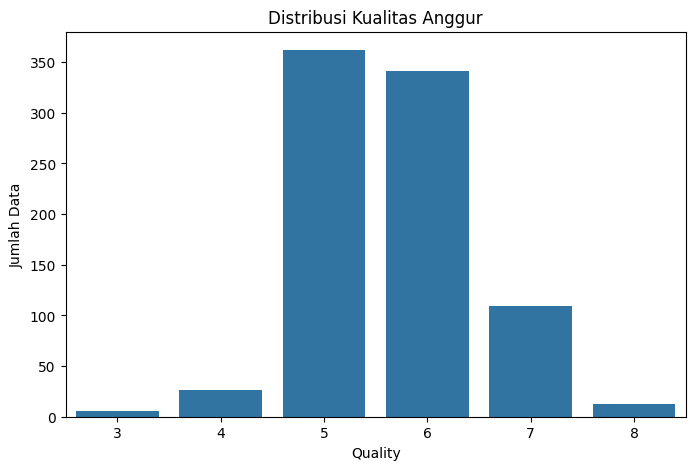

In [4]:
# Visualisasi distribusi quality
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=train_df)

plt.title('Distribusi Kualitas Anggur')
plt.xlabel('Quality')
plt.ylabel('Jumlah Data')

plt.show()

Tahap ini dilakukan untuk melihat distribusi jumlah data pada setiap kelas kualitas anggur (quality). Visualisasi distribusi kelas membantu mengetahui apakah data seimbang atau tidak. Ketidakseimbangan data dapat mempengaruhi performa model klasifikasi dalam melakukan prediksi.

CEK IMBALANCE CLASS

Analisis imbalance class dilakukan untuk mengetahui apakah jumlah data pada setiap kelas kualitas anggur memiliki distribusi yang seimbang. Jika terdapat perbedaan jumlah data yang terlalu besar antar kelas, maka model dapat menjadi bias terhadap kelas mayoritas. Oleh karena itu, pengecekan distribusi kelas penting dilakukan sebelum proses pelatihan model klasifikasi.

In [5]:
train_df['quality'].value_counts()

,count
quality,
5,362
6,341
7,109
4,26
8,13
3,6


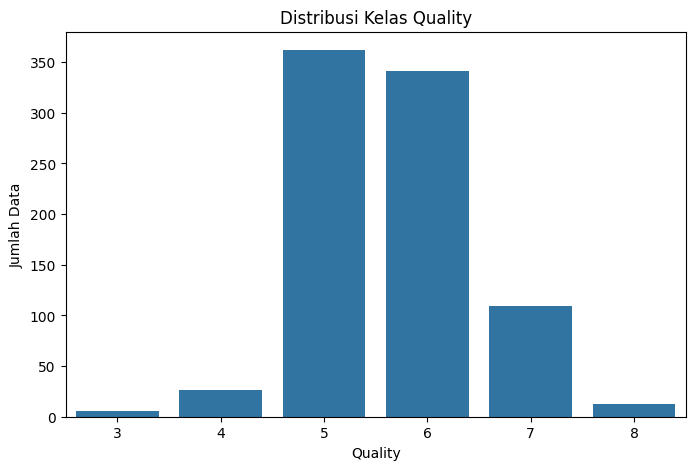

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(x='quality', data=train_df)

plt.title('Distribusi Kelas Quality')
plt.xlabel('Quality')
plt.ylabel('Jumlah Data')

plt.show()

1. MODEL LOGISTIC REGRESSION

Pada tahap ini digunakan algoritma Logistic Regression sebagai model klasifikasi untuk memprediksi kualitas anggur. Logistic Regression merupakan metode klasifikasi yang bekerja dengan memodelkan probabilitas suatu data terhadap kelas tertentu berdasarkan hubungan antara fitur input dan variabel target. Model ini cukup sederhana namun efektif untuk berbagai permasalahan klasifikasi.

In [7]:
#input model logistik regression
from sklearn.linear_model import LogisticRegression

Memisahkan Fitur dan Target

Pada tahap ini dilakukan pemisahan antara variabel fitur (X) dan variabel target (y). Variabel target yang diprediksi adalah quality, sedangkan seluruh fitur kimiawi anggur digunakan sebagai variabel input model. Kolom Id tidak digunakan dalam proses pelatihan model karena hanya berfungsi sebagai identitas data.

In [8]:
X = train_df.drop(columns=['quality', 'Id'])
y = train_df['quality']

In [9]:
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0
...,...,...,...,...,...,...,...,...,...,...,...
852,6.7,1.040,0.08,2.3,0.067,19.0,32.0,0.99648,3.52,0.57,11.0
853,8.0,0.390,0.30,1.9,0.074,32.0,84.0,0.99717,3.39,0.61,9.0
854,7.4,0.350,0.33,2.4,0.068,9.0,26.0,0.99470,3.36,0.60,11.9
855,7.9,0.570,0.31,2.0,0.079,10.0,79.0,0.99677,3.29,0.69,9.5


In [10]:
y

,quality
0,5
1,5
2,7
3,6
4,6
...,...
852,4
853,5
854,6
855,6


Membagi Data Training dan Testing

Dataset dibagi menjadi data training dan data testing menggunakan metode train_test_split. Sebanyak 70% data digunakan untuk pelatihan model dan 30% digunakan untuk pengujian model. Parameter stratify=y digunakan agar distribusi kelas pada data training dan testing tetap seimbang sesuai distribusi data asli.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [12]:
X_test.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
119,8.1,0.870,0.00,2.2,0.084,10.0,31.0,0.99656,3.25,0.50,9.8
394,8.7,0.540,0.26,2.5,0.097,7.0,31.0,0.99760,3.27,0.60,9.3
457,7.0,0.230,0.40,1.6,0.063,21.0,67.0,0.99520,3.50,0.63,11.1
696,10.2,0.490,0.63,2.9,0.072,10.0,26.0,0.99680,3.16,0.78,12.5
846,7.8,0.815,0.01,2.6,0.074,48.0,90.0,0.99621,3.38,0.62,10.8


Data testing hasil pembagian dataset ditampilkan untuk memastikan proses pemisahan data berhasil dilakukan dengan benar sebelum model dilatih.

Membuat Model Logistik Regression

Model Logistic Regression digunakan untuk mempelajari pola hubungan antara fitur kimiawi anggur dengan kualitas anggur (quality). Setelah model dilatih menggunakan data training, dilakukan pengujian menggunakan data testing untuk mengetahui performa model melalui nilai akurasi.

In [13]:
logreg = LogisticRegression(max_iter=1000)

# training model
logreg.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [14]:
# melakukan prediksi
y_pred = logreg.predict(X_test)

In [15]:
# menampilkan hasil prediksi
pd.DataFrame({
    'Actual': y_test,
    'Prediction': y_pred
}).head()

,Actual,Prediction
119,5,5
394,6,5
457,5,6
696,7,7
846,5,5


Setelah model selesai dilatih, dilakukan prediksi terhadap data testing hasil pembagian dataset. Hasil prediksi ini kemudian digunakan untuk mengevaluasi performa model klasifikasi dalam memprediksi kualitas anggur.

In [16]:
accuracy = accuracy_score(y_test, y_pred) * 100

print("Akurasi Model Logistic Regression:", accuracy, "%")

Akurasi Model Logistic Regression: 59.30232558139535 %


Akurasi digunakan untuk mengukur seberapa baik model dalam memprediksi kualitas anggur. Nilai akurasi menunjukkan persentase jumlah prediksi yang benar dibandingkan dengan seluruh data pengujian. Semakin tinggi nilai akurasi, maka performa model semakin baik.


In [17]:
#training logistik regression
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

PREDIKSI DATA TEST

Setelah model Logistic Regression selesai dilatih, model digunakan untuk memprediksi kualitas anggur pada data testing. Hasil prediksi kemudian dibandingkan dengan data aktual untuk mengevaluasi performa model klasifikasi.


In [18]:
pred = logistic_model.predict(X_test)

pred

array([5, 5, 6, 7, 5, 6, 5, 6, 6, 5, 6, 6, 7, 6, 6, 5, 5, 5, 6, 5, 5, 5,
       5, 6, 5, 6, 6, 5, 5, 5, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 5, 7, 6,
       5, 6, 6, 5, 5, 6, 5, 5, 5, 5, 6, 5, 6, 6, 5, 7, 5, 6, 6, 5, 7, 5,
       5, 5, 6, 6, 6, 6, 6, 6, 5, 7, 6, 5, 6, 6, 5, 6, 6, 6, 7, 6, 6, 5,
       5, 6, 5, 5, 7, 5, 5, 5, 5, 5, 5, 6, 7, 6, 6, 7, 6, 5, 5, 5, 6, 5,
       5, 6, 6, 7, 6, 5, 6, 5, 6, 5, 6, 6, 6, 5, 5, 5, 5, 6, 7, 5, 5, 5,
       6, 6, 6, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 5, 6, 6, 5, 5, 5, 5, 6, 5,
       5, 6, 6, 5, 6, 6, 5, 6, 6, 5, 5, 6, 6, 5, 5, 6, 5, 5, 7, 6, 5, 7,
       5, 6, 5, 5, 6, 5, 6, 6, 5, 5, 6, 5, 7, 5, 6, 5, 5, 6, 5, 5, 5, 6,
       6, 5, 6, 6, 7, 6, 6, 6, 5, 5, 7, 6, 5, 5, 5, 6, 7, 5, 6, 5, 5, 5,
       6, 6, 5, 6, 5, 6, 7, 5, 5, 5, 5, 6, 5, 6, 5, 5, 6, 5, 5, 6, 6, 5,
       5, 5, 5, 5, 5, 6, 5, 5, 6, 5, 7, 6, 5, 6, 6, 6])

In [19]:
#menggabungkan hasil prediksi
X_test1 = X_test.copy()

X_test1['quality_pred'] = pred
X_test1['quality_actual'] = y_test.values

X_test1.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality_pred,quality_actual
119,8.1,0.870,0.00,2.2,0.084,10.0,31.0,0.99656,3.25,0.50,9.8,5,5
394,8.7,0.540,0.26,2.5,0.097,7.0,31.0,0.99760,3.27,0.60,9.3,5,6
457,7.0,0.230,0.40,1.6,0.063,21.0,67.0,0.99520,3.50,0.63,11.1,6,5
696,10.2,0.490,0.63,2.9,0.072,10.0,26.0,0.99680,3.16,0.78,12.5,7,7
846,7.8,0.815,0.01,2.6,0.074,48.0,90.0,0.99621,3.38,0.62,10.8,5,5


Hasil prediksi model digabungkan dengan data testing untuk membandingkan nilai kualitas aktual dan hasil prediksi model. Tahap ini membantu dalam analisis performa model secara lebih detail.

In [20]:
accuracy = accuracy_score(y_test, pred) * 100

print("Akurasi Model Logistic Regression:", accuracy, "%")

Akurasi Model Logistic Regression: 59.30232558139535 %


2. Model KNN (K-Nearest Neighbors)

In [21]:
#import model KNN
from sklearn.neighbors import KNeighborsClassifier

In [22]:
#feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
#training model KNN
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=7)

knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=7)

Model K-Nearest Neighbors (KNN) dilatih menggunakan data training yang telah melalui proses scaling. Pada penelitian ini digunakan nilai k = 7, yang berarti model akan mempertimbangkan 7 tetangga terdekat dalam menentukan kelas kualitas anggur.

In [24]:
#prediksi dan evaluasi KNN
pred_knn = knn_model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score

accuracy_score(y_test, pred_knn) * 100

53.875968992248055

Setelah model KNN dilatih, dilakukan prediksi pada data testing yang telah melalui proses scaling. Hasil prediksi kemudian dievaluasi menggunakan metrik akurasi untuk mengetahui kemampuan model dalam memprediksi kualitas anggur secara tepat.

In [25]:
#Hasil prediksi KNN
pd.DataFrame({
    'Actual': y_test,
    'Prediction': y_pred
}).head()

,Actual,Prediction
119,5,5
394,6,5
457,5,6
696,7,7
846,5,5


In [26]:
#feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
#mecari nilai K terbaik
neighbors_list = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]

train_accuracy_list = []
test_accuracy_list = []

for neighbor_num in neighbors_list:

    knn_model = KNeighborsClassifier(n_neighbors=neighbor_num)

    knn_model.fit(X_train_scaled, y_train)

    train_pred = knn_model.predict(X_train_scaled)
    test_pred = knn_model.predict(X_test_scaled)

    train_acc_score = accuracy_score(y_train, train_pred) * 100
    test_acc_score = accuracy_score(y_test, test_pred) * 100

    train_accuracy_list.append(train_acc_score)
    test_accuracy_list.append(test_acc_score)

    print(
        "Neighbors_num: {0} --> Accuracy on Test Set: {1} %"
        .format(neighbor_num, np.round(test_acc_score, 2))
    )

Neighbors_num: 1 --> Accuracy on Test Set: 54.26 %
Neighbors_num: 3 --> Accuracy on Test Set: 47.29 %
Neighbors_num: 5 --> Accuracy on Test Set: 51.94 %
Neighbors_num: 7 --> Accuracy on Test Set: 53.88 %
Neighbors_num: 9 --> Accuracy on Test Set: 55.04 %
Neighbors_num: 11 --> Accuracy on Test Set: 55.81 %
Neighbors_num: 13 --> Accuracy on Test Set: 55.04 %
Neighbors_num: 15 --> Accuracy on Test Set: 56.2 %
Neighbors_num: 17 --> Accuracy on Test Set: 55.81 %
Neighbors_num: 19 --> Accuracy on Test Set: 53.88 %
Neighbors_num: 21 --> Accuracy on Test Set: 53.88 %


Pada tahap ini dilakukan pengujian beberapa nilai k pada algoritma KNN untuk mencari jumlah tetangga terbaik yang menghasilkan performa paling optimal. Nilai akurasi pada data training dan testing dibandingkan untuk menentukan model dengan generalisasi terbaik.

In [28]:
performance_df = pd.DataFrame({
    'Neighbors_num': neighbors_list,
    'Train Accuracy': train_accuracy_list,
    'Test Accuracy': test_accuracy_list
})

performance_df

,Neighbors_num,Train Accuracy,Test Accuracy
0,1,100.000000,54.263566
1,3,75.125209,47.286822
2,5,68.447412,51.937984
3,7,65.776294,53.875969
4,9,63.772955,55.038760
5,11,63.105175,55.813953
6,13,60.934891,55.038760
7,15,60.434057,56.201550
8,17,61.435726,55.813953
9,19,60.100167,53.875969


DataFrame dibuat untuk membandingkan performa model KNN pada berbagai nilai k. Perbandingan dilakukan berdasarkan nilai akurasi pada data training dan testing sehingga dapat dipilih nilai k yang memberikan performa terbaik.

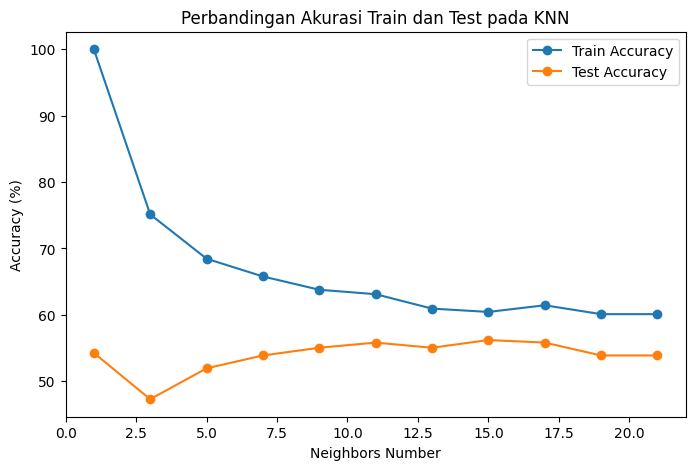

In [29]:
#visualisasi akurasi KNN
plt.figure(figsize=(8,5))

plt.plot(
    performance_df['Neighbors_num'],
    performance_df['Train Accuracy'],
    marker='o'
)

plt.plot(
    performance_df['Neighbors_num'],
    performance_df['Test Accuracy'],
    marker='o'
)

plt.xlabel("Neighbors Number")
plt.ylabel("Accuracy (%)")

plt.title("Perbandingan Akurasi Train dan Test pada KNN")

plt.legend(['Train Accuracy', 'Test Accuracy'])

plt.show()

Grafik digunakan untuk membandingkan akurasi data training dan data testing pada berbagai nilai k dalam algoritma KNN. Nilai k terbaik dipilih berdasarkan akurasi testing tertinggi dengan mempertimbangkan keseimbangan antara performa training dan testing agar model tidak mengalami overfitting maupun underfitting.

Confusion matrix digunakan untuk melihat performa model dalam memprediksi setiap kelas kualitas anggur secara lebih detail, termasuk jumlah prediksi benar dan salah. Sedangkan classification report memberikan metrik seperti precision, recall, dan f1-score untuk mengevaluasi performa model secara lebih menyeluruh pada setiap kelas.

In [30]:
#evaluasi model KNN
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[ 0  0  2  0  0  0]
 [ 0  0  4  3  1  0]
 [ 0  0 88 19  2  0]
 [ 0  0 36 57  9  0]
 [ 0  0  0 25  8  0]
 [ 0  0  0  4  0  0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         8
           5       0.68      0.81      0.74       109
           6       0.53      0.56      0.54       102
           7       0.40      0.24      0.30        33
           8       0.00      0.00      0.00         4

    accuracy                           0.59       258
   macro avg       0.27      0.27      0.26       258
weighted avg       0.55      0.59      0.56       258



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Berdasarkan hasil evaluasi, model menunjukkan performa yang bervariasi pada setiap kelas kualitas, yang dipengaruhi oleh distribusi data yang tidak seimbang dan kompleksitas hubungan antar fitur.

3. Model Decision Tree

In [31]:
#import decision tree
from sklearn.tree import DecisionTreeClassifier

Decision Tree Classifier merupakan algoritma klasifikasi yang bekerja dengan membentuk struktur pohon keputusan berdasarkan aturan-aturan dari fitur data. Model ini memecah data secara berulang berdasarkan fitur yang paling informatif untuk memisahkan kelas target sehingga menghasilkan prediksi yang lebih akurat.

In [32]:
#training decision tree
classifier = DecisionTreeClassifier(random_state=42)

classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Model Decision Tree Classifier dilatih menggunakan data training untuk mempelajari pola hubungan antara fitur kimiawi anggur dan kualitasnya. Parameter random_state digunakan agar hasil model konsisten setiap kali dijalankan.

In [33]:
#prediksi decision tree
y_pred = classifier.predict(X_test)

Setelah model Decision Tree dilatih, dilakukan prediksi pada data testing untuk mengetahui kemampuan model dalam mengklasifikasikan kualitas anggur berdasarkan fitur yang tersedia.

Evaluasi model Decision Tree dilakukan menggunakan confusion matrix dan classification report. Confusion matrix menunjukkan jumlah prediksi benar dan salah untuk setiap kelas, sedangkan classification report memberikan metrik evaluasi seperti precision, recall, dan f1-score untuk setiap kelas kualitas anggur.

In [34]:
#evaluasi decision tree
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[ 0  0  1  1  0  0]
 [ 1  0  3  3  1  0]
 [ 3  3 66 34  2  1]
 [ 0  4 25 64  7  2]
 [ 0  2  4 14 11  2]
 [ 0  0  0  0  3  1]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         8
           5       0.67      0.61      0.63       109
           6       0.55      0.63      0.59       102
           7       0.46      0.33      0.39        33
           8       0.17      0.25      0.20         4

    accuracy                           0.55       258
   macro avg       0.31      0.30      0.30       258
weighted avg       0.56      0.55      0.55       258



Berdasarkan hasil evaluasi, model Decision Tree mampu memberikan performa yang cukup baik dalam memprediksi kualitas anggur, namun hasilnya dapat dipengaruhi oleh kedalaman pohon dan kompleksitas data.

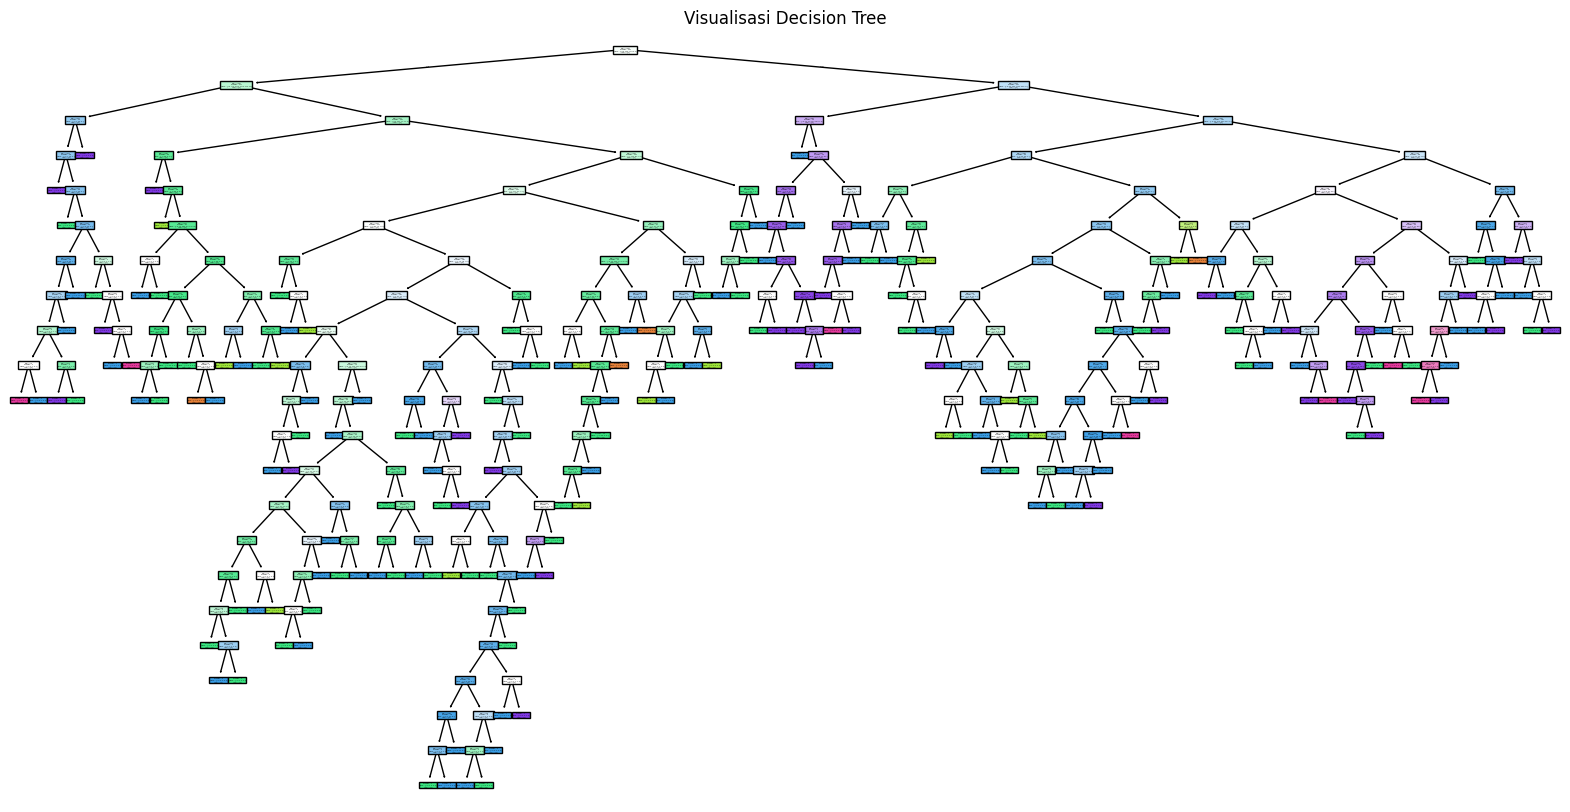

In [35]:
#visualisasi decision tree
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    classifier,
    filled=True,
    feature_names=X_train.columns,
    class_names=True
)

plt.title("Visualisasi Decision Tree")
plt.show()

Visualisasi Decision Tree dilakukan untuk melihat struktur pengambilan keputusan model dalam melakukan klasifikasi kualitas anggur. Setiap node pada pohon menunjukkan aturan berdasarkan fitur tertentu yang digunakan untuk memisahkan data ke dalam kelas yang berbeda. Visualisasi ini membantu dalam memahami bagaimana model bekerja secara intuitif.

In [36]:
#Training Decision Tree dengan max_depth
#decision tree (dengan max depth)
classifier = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

classifier.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [37]:
#Evaluasi ulang
y_pred = classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred) * 100)

Accuracy: 55.03875968992248


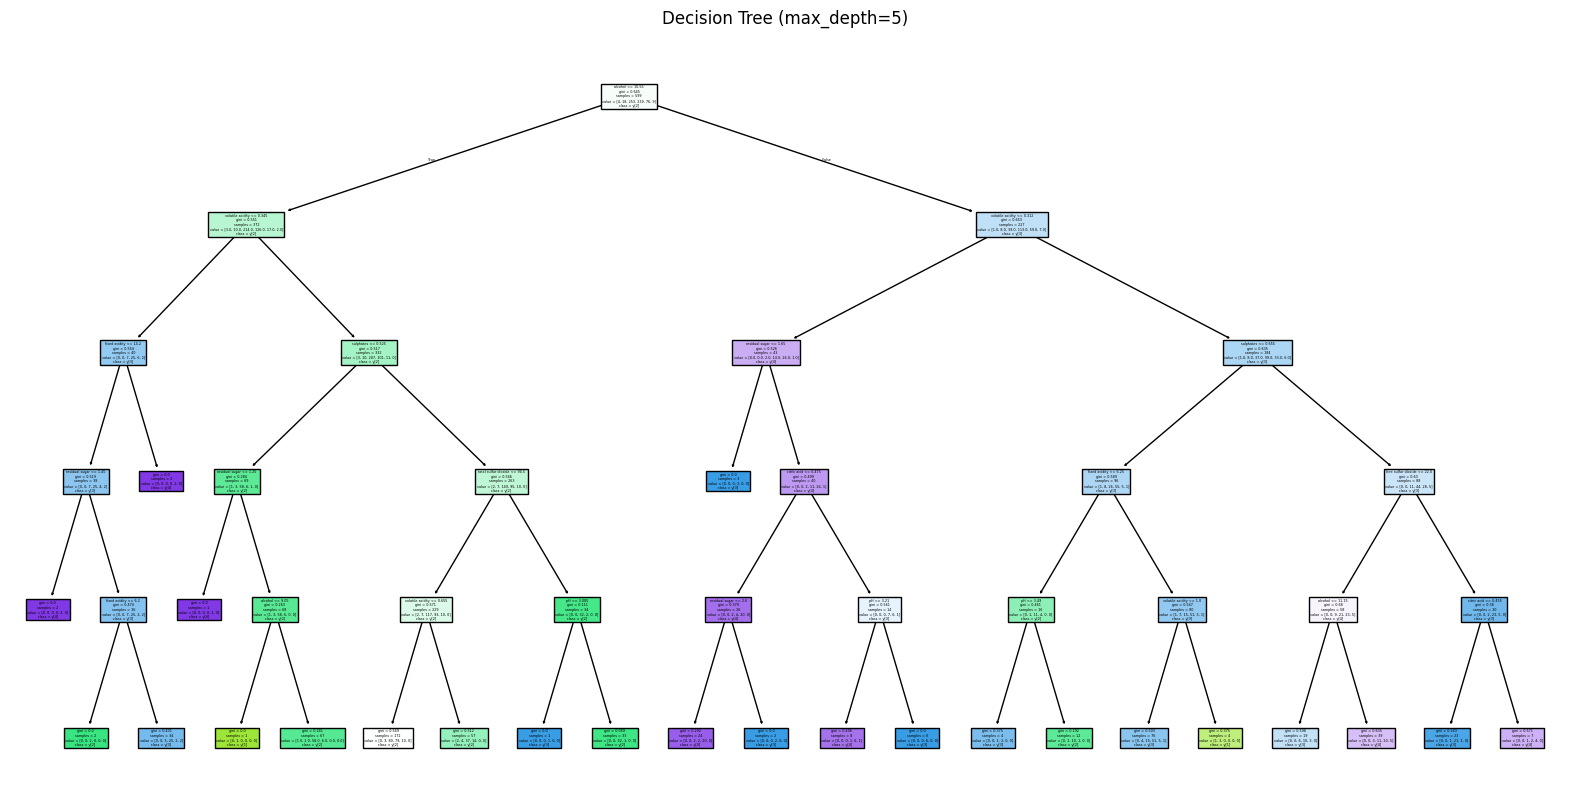

In [38]:
#Visualisasi tree (lebih kecil & jelas)
plt.figure(figsize=(20, 10))

plot_tree(
    classifier,
    filled=True,
    feature_names=X_train.columns,
    class_names=True
)

plt.title("Decision Tree (max_depth=5)")
plt.show()

Pada model Decision Tree tanpa pembatasan kedalaman, model cenderung mengalami overfitting karena terlalu kompleks dalam mempelajari data training. Hal ini terlihat dari perbedaan performa antara data training dan testing.

Oleh karena itu, dilakukan pembatasan max_depth=5 untuk mengurangi kompleksitas model agar dapat meningkatkan generalisasi terhadap data baru. Dengan pembatasan ini, model menjadi lebih sederhana dan diharapkan mampu memberikan performa yang lebih stabil pada data testing.

4. Model Random Forest

Random Forest Classifier merupakan metode ensemble learning yang terdiri dari banyak decision tree. Setiap pohon memberikan hasil prediksi, kemudian hasil akhir ditentukan berdasarkan voting mayoritas. Model ini umumnya memiliki performa yang lebih baik dibandingkan Decision Tree tunggal karena lebih stabil dan mengurangi risiko overfitting.

In [39]:
#random forest classifier
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state=42)

rfc.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [40]:
#prediksi random forest
y_pred = rfc.predict(X_test)

y_pred

array([5, 6, 6, 7, 6, 6, 5, 6, 5, 5, 6, 5, 7, 6, 7, 5, 5, 6, 5, 5, 5, 5,
       5, 6, 5, 5, 7, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 5, 6, 6,
       5, 6, 6, 5, 5, 6, 5, 5, 5, 5, 7, 6, 7, 6, 5, 6, 5, 7, 6, 5, 6, 5,
       5, 5, 5, 6, 5, 6, 8, 7, 6, 6, 6, 6, 6, 6, 5, 6, 6, 6, 5, 6, 5, 5,
       5, 6, 6, 5, 7, 5, 5, 5, 5, 5, 5, 6, 7, 7, 5, 6, 6, 5, 5, 5, 6, 5,
       5, 7, 6, 6, 7, 5, 6, 5, 6, 5, 6, 5, 6, 5, 5, 5, 5, 5, 6, 6, 5, 5,
       6, 6, 5, 5, 5, 6, 6, 5, 6, 6, 6, 7, 6, 5, 6, 7, 5, 5, 5, 5, 6, 5,
       5, 6, 6, 6, 5, 6, 5, 6, 6, 6, 5, 5, 5, 5, 5, 6, 5, 5, 6, 5, 5, 6,
       5, 7, 6, 5, 6, 5, 6, 6, 5, 5, 6, 5, 7, 5, 7, 5, 6, 6, 5, 5, 5, 6,
       6, 5, 6, 7, 7, 6, 6, 6, 6, 6, 7, 6, 5, 5, 5, 6, 6, 6, 6, 5, 5, 5,
       6, 6, 5, 6, 5, 6, 7, 5, 5, 5, 5, 6, 5, 6, 6, 6, 5, 5, 6, 6, 6, 5,
       5, 5, 5, 6, 5, 6, 5, 5, 6, 6, 6, 5, 5, 6, 6, 6])

Pada tahap ini dilakukan prediksi menggunakan model Random Forest Classifier terhadap data testing. Hasil prediksi kemudian digunakan untuk mengevaluasi performa model dalam mengklasifikasikan kualitas anggur.

In [41]:
print('Model accuracy score with Random Forest : {0:0.4f}'.format(
    accuracy_score(y_test, y_pred)
))

Model accuracy score with Random Forest : 0.6240


Akurasi digunakan untuk mengukur performa model Random Forest dalam memprediksi kualitas anggur. Nilai akurasi menunjukkan persentase prediksi yang benar dibandingkan dengan total data pengujian.

In [42]:
#hyperparameter tuning decision tree
max_depth_tree_list = np.arange(1, 20, 2)

tree_params_list = {
    'max_depth': max_depth_tree_list,
    'criterion': ['gini', 'entropy']  # log_loss biasanya untuk classifier probabilistik, tidak wajib di DT
}

Pada tahap ini dilakukan tuning hyperparameter untuk model Decision Tree menggunakan beberapa nilai max_depth dan criterion. Tujuan dari proses ini adalah untuk mencari kombinasi parameter terbaik yang menghasilkan performa model paling optimal.

In [43]:
#perbandingan akurasi model
print("Logistic Regression Accuracy:", accuracy_score(y_test, logreg.predict(X_test)) * 100)
print("KNN Accuracy:", accuracy_score(y_test, knn_model.predict(X_test_scaled)) * 100)
print("Decision Tree Accuracy:", accuracy_score(y_test, classifier.predict(X_test)) * 100)
print("Random Forest Accuracy:", accuracy_score(y_test, rfc.predict(X_test)) * 100)

Logistic Regression Accuracy: 59.30232558139535
KNN Accuracy: 53.875968992248055
Decision Tree Accuracy: 55.03875968992248
Random Forest Accuracy: 62.4031007751938


In [44]:
best_model = rfc

In [45]:
best_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [46]:
#prediksi data testing asli
X_final_test = test_df.drop(columns=['Id'])  # hanya fitur

final_pred = best_model.predict(X_final_test)

final_pred

array([5, 6, 5, 5, 6, 6, 6, 5, 6, 5, 7, 7, 5, 6, 5, 5, 6, 6, 5, 7, 6, 7,
       5, 7, 5, 5, 6, 6, 5, 6, 6, 5, 7, 6, 5, 5, 6, 6, 7, 6, 7, 6, 6, 5,
       5, 5, 6, 6, 5, 6, 6, 5, 6, 7, 6, 7, 6, 6, 5, 5, 5, 6, 6, 7, 6, 6,
       7, 5, 5, 6, 7, 5, 5, 5, 6, 5, 6, 6, 5, 6, 5, 6, 5, 5, 5, 6, 5, 5,
       6, 6, 5, 6, 5, 5, 5, 5, 6, 6, 5, 5, 6, 6, 5, 6, 5, 5, 6, 6, 6, 7,
       6, 5, 5, 6, 5, 5, 5, 7, 6, 5, 5, 5, 5, 6, 5, 5, 6, 6, 5, 6, 5, 5,
       7, 6, 7, 5, 5, 6, 6, 6, 7, 5, 5, 5, 7, 6, 5, 5, 5, 5, 6, 5, 6, 5,
       6, 5, 5, 5, 7, 6, 5, 5, 6, 6, 6, 5, 5, 6, 5, 5, 6, 5, 5, 6, 5, 5,
       7, 6, 6, 5, 6, 5, 6, 5, 5, 5, 6, 5, 6, 6, 6, 6, 6, 6, 6, 6, 5, 6,
       7, 6, 5, 6, 5, 5, 6, 7, 5, 5, 6, 6, 5, 6, 5, 6, 5, 6, 6, 5, 7, 5,
       5, 5, 5, 5, 5, 6, 6, 5, 6, 6, 7, 7, 6, 5, 6, 7, 5, 6, 6, 5, 6, 6,
       6, 5, 5, 6, 5, 5, 6, 5, 5, 5, 5, 6, 5, 6, 7, 5, 6, 5, 5, 6, 7, 5,
       5, 5, 6, 6, 5, 6, 6, 7, 5, 6, 5, 6, 5, 6, 6, 5, 5, 6, 5, 5, 6, 7])

In [48]:
#export hasil prediksi
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'quality': final_pred
})

submission.to_csv("hasilprediksi_048.csv", index=False)

submission.head()

,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,6


Berdasarkan hasil perbandingan beberapa model klasifikasi, Random Forest memberikan performa terbaik dibandingkan model lainnya. Oleh karena itu, model tersebut dipilih sebagai model akhir untuk melakukan prediksi kualitas anggur pada data testing.